<a href="https://colab.research.google.com/github/pankajkumar8709/Machine-Learning-projects/blob/main/SVM.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

About SVM and its Mathematical Intuition
https://medium.com/data-science/explain-support-vector-machines-in-mathematic-details-c7cc1be9f3b9

when to use
https://christianbernecker.medium.com/support-vector-machines-svm-with-python-and-scikit-learn-d814ff6e8be1


## When to Use SVM

Support Vector Machine (SVM) is a supervised machine learning algorithm mainly used for **classification**, and in some cases for **regression**. It works best when the goal is to find a clear boundary between classes.

### SVM is suitable for the following types of datasets:

**1. Small to medium-sized datasets**
SVM performs well when the dataset is not very large. It is effective in cases where the number of samples is limited.

**2. High-dimensional datasets**
SVM works very well when the number of features is large, such as in:

* Text classification
* Document classification
* Spam detection
* Image recognition with extracted features

**3. Linearly separable datasets**
If the classes can be separated by a straight line in 2D or a hyperplane in higher dimensions, SVM gives very good results.

**4. Non-linear datasets**
When the data is not linearly separable, SVM can still work well by using **kernel functions** such as:

* Linear kernel
* Polynomial kernel
* RBF (Radial Basis Function) kernel
* Sigmoid kernel

**5. Datasets with clear margins between classes**
SVM is powerful when there is a distinct gap between classes and the model can maximize the margin.

### SVM is commonly used for:

* Binary classification problems
* Text classification
* Spam detection
* Face recognition
* Medical diagnosis
* Handwriting recognition

### SVM is not the best choice when:

* The dataset is very large
* The data contains too much noise
* The classes overlap heavily
* The training time needs to be very fast
* The problem has many irrelevant features without proper preprocessing

### Conclusion

SVM is best used for **small to medium datasets**, especially when the data has **many features** and the classes are **clearly separable** or can be separated using a kernel trick. It is one of the best algorithms for classification tasks where accuracy is important and the dataset is not extremely large.


In [2]:
!pip install ucimlrepo

In [3]:
from ucimlrepo import fetch_ucirepo

# fetch dataset
breast_cancer_wisconsin_original = fetch_ucirepo(id=15)

# data (as pandas dataframes)
X = breast_cancer_wisconsin_original.data.features
y = breast_cancer_wisconsin_original.data.targets

# metadata
print(breast_cancer_wisconsin_original.metadata)

# variable information
print(breast_cancer_wisconsin_original.variables)


{'uci_id': 15, 'name': 'Breast Cancer Wisconsin (Original)', 'repository_url': 'https://archive.ics.uci.edu/dataset/15/breast+cancer+wisconsin+original', 'data_url': 'https://archive.ics.uci.edu/static/public/15/data.csv', 'abstract': 'Original Wisconsin Breast Cancer Database', 'area': 'Health and Medicine', 'tasks': ['Classification'], 'characteristics': ['Multivariate'], 'num_instances': 699, 'num_features': 9, 'feature_types': ['Integer'], 'demographics': [], 'target_col': ['Class'], 'index_col': ['Sample_code_number'], 'has_missing_values': 'yes', 'missing_values_symbol': 'NaN', 'year_of_dataset_creation': 1990, 'last_updated': 'Sun Mar 10 2024', 'dataset_doi': '10.24432/C5HP4Z', 'creators': ['WIlliam Wolberg'], 'intro_paper': None, 'additional_info': {'summary': "Samples arrive periodically as Dr. Wolberg reports his clinical cases. The database therefore reflects this chronological grouping of the data. This grouping information appears immediately below, having been removed fro

In [12]:
y['Class'].unique()

array([2, 4])

In [14]:
X.sample(5)

,Clump_thickness,Uniformity_of_cell_size,Uniformity_of_cell_shape,Marginal_adhesion,Single_epithelial_cell_size,Bare_nuclei,Bland_chromatin,Normal_nucleoli,Mitoses
652,5,1,1,1,2,1.0,2,2,1
509,2,1,1,1,2,1.0,1,1,1
36,10,10,10,8,6,1.0,8,9,1
528,6,1,3,2,2,1.0,1,1,1
357,8,10,10,7,10,10.0,7,3,8


In [16]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.svm import SVC
from sklearn.metrics import classification_report,accuracy_score,confusion_matrix

<Axes: xlabel='Clump_thickness', ylabel='Single_epithelial_cell_size'>

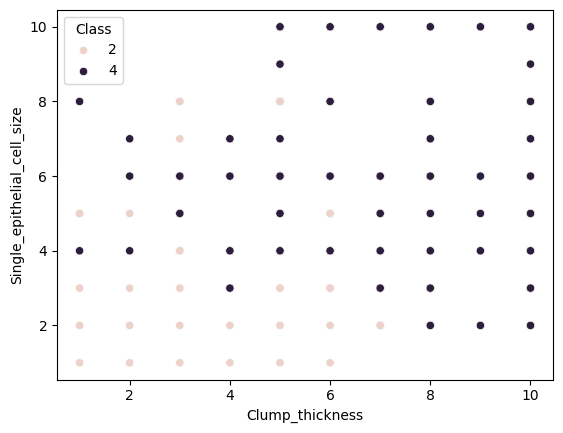

In [23]:
sns.scatterplot(X,x=X['Clump_thickness'],y=X['Single_epithelial_cell_size'],hue=y['Class'])

<Axes: xlabel='Clump_thickness', ylabel='Uniformity_of_cell_shape'>

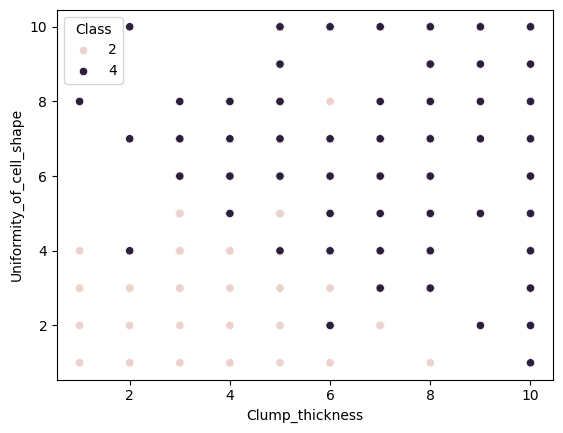

In [21]:
sns.scatterplot(X,x=X['Clump_thickness'],y=X['Uniformity_of_cell_shape'],hue=y['Class'])

<Axes: xlabel='Clump_thickness', ylabel='Uniformity_of_cell_size'>

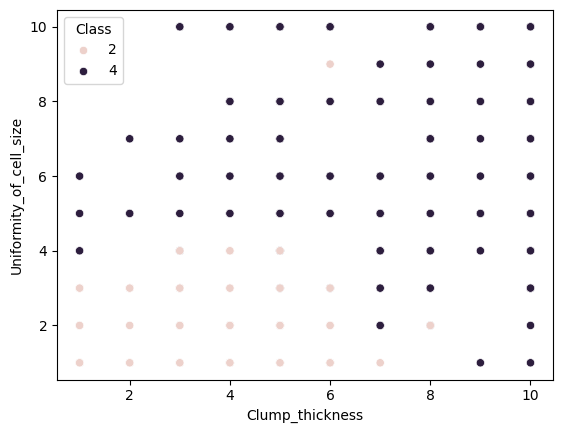

In [20]:
sns.scatterplot(X,x=X['Clump_thickness'],y=X['Uniformity_of_cell_size'],hue=y['Class'])

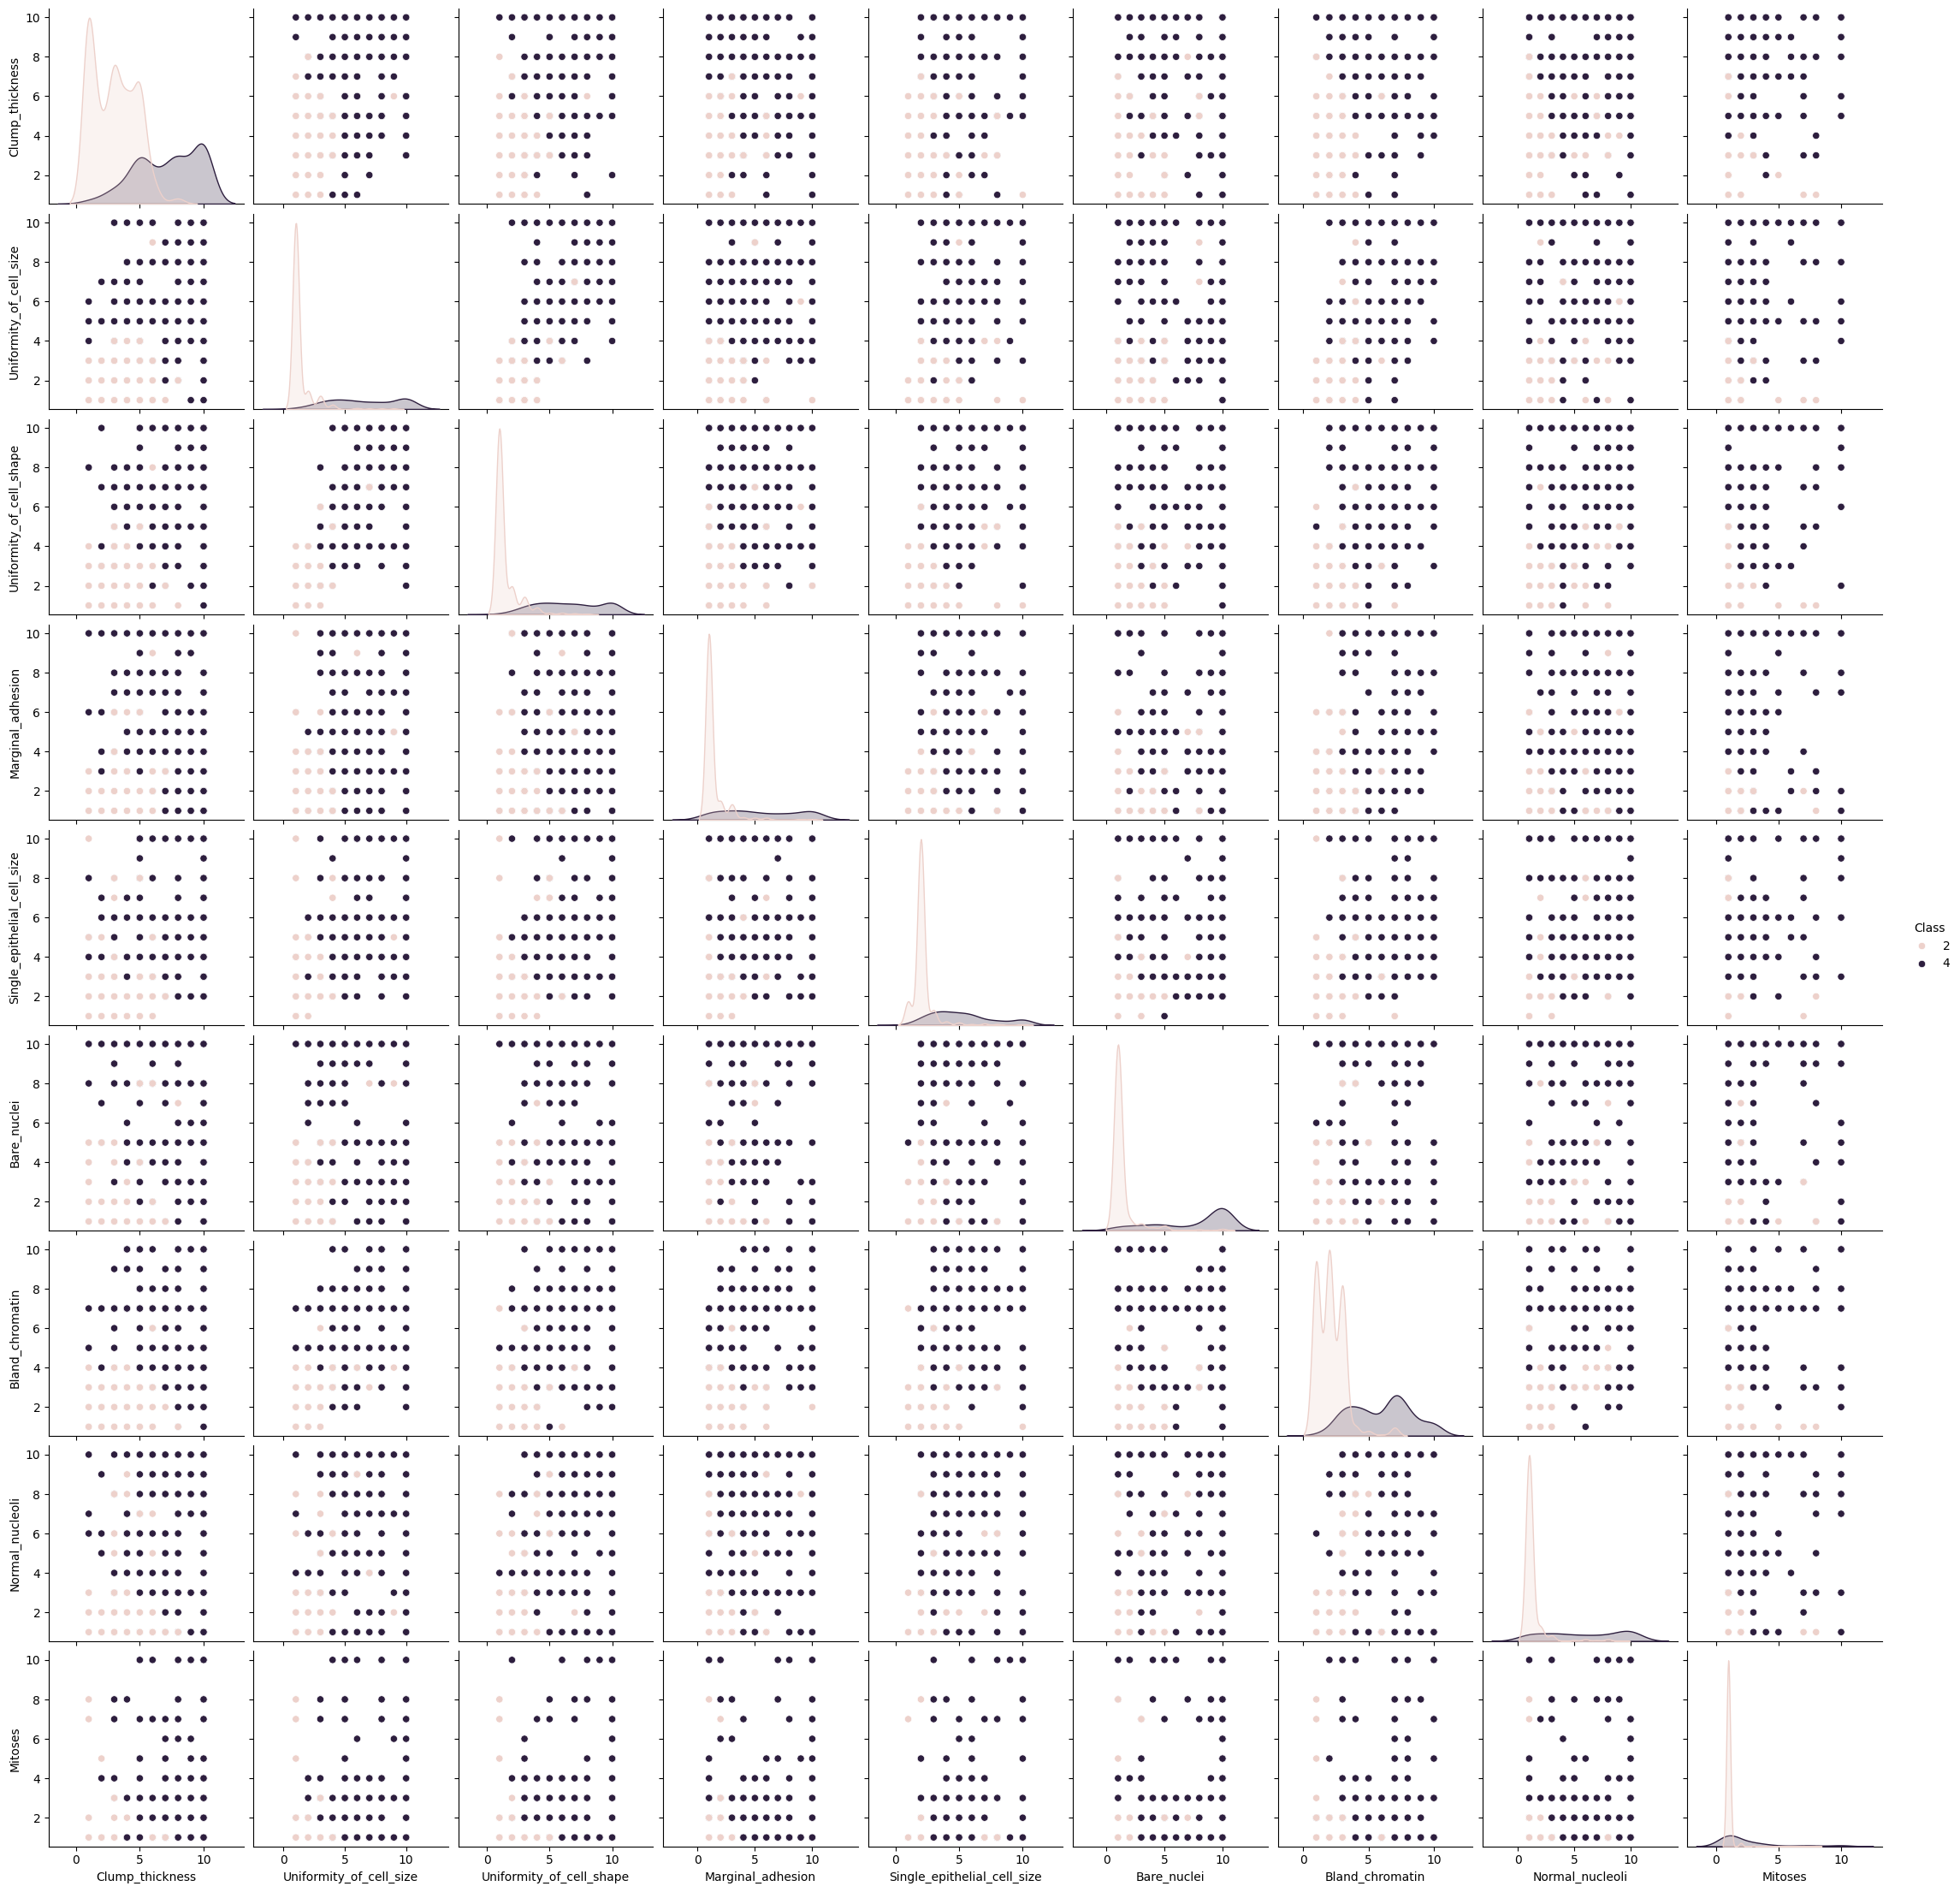

In [25]:
df = pd.concat([X, y], axis=1)
sns.pairplot(df, hue='Class')

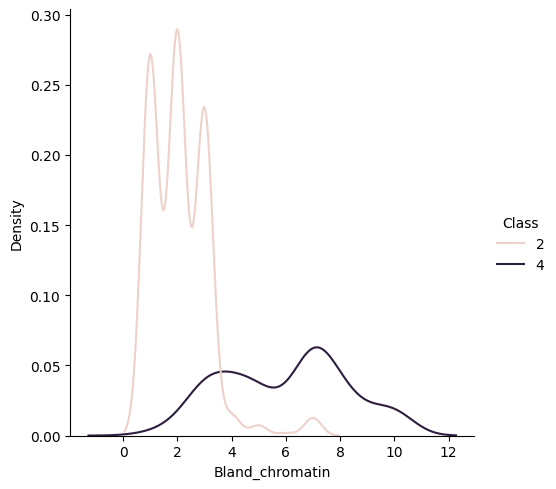

In [31]:
sns.displot(df,x='Bland_chromatin',hue='Class',kind='kde')

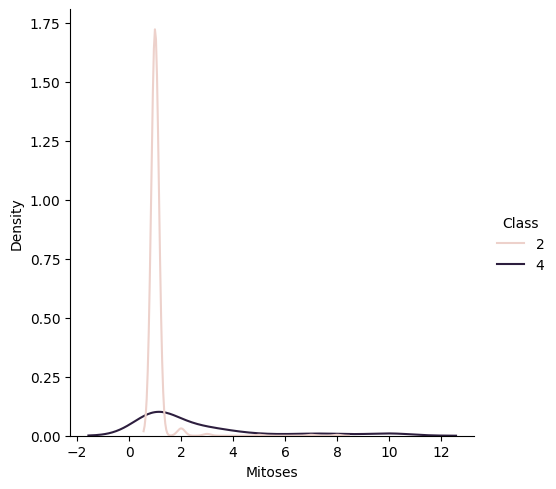

In [28]:
sns.displot(df,x='Mitoses',hue='Class',kind='kde')

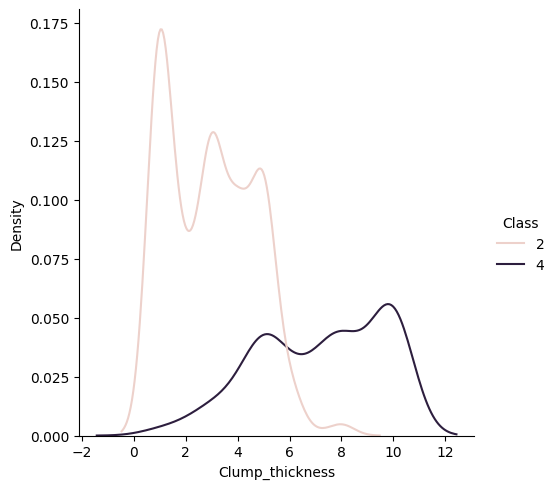

In [27]:
sns.displot(df,x='Clump_thickness',hue='Class',kind='kde')

In [32]:
x_train,x_test,y_train,y_test = train_test_split(X,y,test_size=0.3,random_state=101)

In [33]:
X.isnull().sum()

,0
Clump_thickness,0
Uniformity_of_cell_size,0
Uniformity_of_cell_shape,0
Marginal_adhesion,0
Single_epithelial_cell_size,0
Bare_nuclei,16
Bland_chromatin,0
Normal_nucleoli,0
Mitoses,0


In [34]:
from sklearn.impute import SimpleImputer
imputer = SimpleImputer(strategy='mean')
imputer.fit(x_train)
x_train = imputer.transform(x_train)
x_test = imputer.transform(x_test)

In [36]:
x_train=pd.DataFrame(x_train,columns=X.columns)
x_test=pd.DataFrame(x_test,columns=X.columns)

In [38]:
x_train.isnull().sum(),x_test.isnull().sum()

(Clump_thickness                0
 Uniformity_of_cell_size        0
 Uniformity_of_cell_shape       0
 Marginal_adhesion              0
 Single_epithelial_cell_size    0
 Bare_nuclei                    0
 Bland_chromatin                0
 Normal_nucleoli                0
 Mitoses                        0
 dtype: int64,
 Clump_thickness                0
 Uniformity_of_cell_size        0
 Uniformity_of_cell_shape       0
 Marginal_adhesion              0
 Single_epithelial_cell_size    0
 Bare_nuclei                    0
 Bland_chromatin                0
 Normal_nucleoli                0
 Mitoses                        0
 dtype: int64)

In [39]:
y_train.isnull().sum(),y_test.isnull().sum()

(Class    0
 dtype: int64,
 Class    0
 dtype: int64)

In [40]:
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
scaler.fit(x_train)
x_train = scaler.transform(x_train)
x_test = scaler.transform(x_test)

In [75]:
from sklearn.svm import SVC
model = SVC(kernel='linear') #kernel{‘linear’, ‘poly’, ‘rbf’, ‘sigmoid’, ‘precomputed’} or callable, default=’rbf’
model.fit(x_train,y_train)

/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:1408: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)


SVC(kernel='linear')

In [76]:
y_pred = model.predict(x_test)

In [74]:
accuracy_score(y_test,y_pred)

0.9476190476190476

In [44]:
confusion_matrix(y_test,y_pred)

array([[127,   2],
       [  3,  78]])

In [46]:
from sklearn.linear_model import LogisticRegression
model = LogisticRegression()
model.fit(x_train,y_train)

/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:1408: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)


LogisticRegression()

In [47]:
y_pred2=model.predict(x_test)

In [48]:
accuracy_score(y_test,y_pred2)

0.9619047619047619

In [49]:
confusion_matrix(y_test,y_pred2)

array([[127,   2],
       [  6,  75]])

In [50]:
from sklearn.tree import DecisionTreeClassifier
model = DecisionTreeClassifier()
model.fit(x_train,y_train)

DecisionTreeClassifier()

In [51]:
y_pred3=model.predict(x_test)

In [52]:
accuracy_score(y_test,y_pred3)

0.9428571428571428

In [54]:
from sklearn.ensemble import RandomForestClassifier
model = RandomForestClassifier()
model.fit(x_train,y_train)

/usr/local/lib/python3.12/dist-packages/sklearn/base.py:1389: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples,), for example using ravel().
  return fit_method(estimator, *args, **kwargs)


RandomForestClassifier()

In [55]:
y_pred4=model.predict(x_test)

In [56]:
accuracy_score(y_test,y_pred4)

0.9571428571428572

In [57]:
from sklearn.neighbors import KNeighborsClassifier
model = KNeighborsClassifier()
model.fit(x_train,y_train)

/usr/local/lib/python3.12/dist-packages/sklearn/neighbors/_classification.py:239: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples,), for example using ravel().
  return self._fit(X, y)


KNeighborsClassifier()

In [58]:
y_pred5=model.predict(x_test)

In [59]:
accuracy_score(y_test,y_pred5)

0.9714285714285714

In [60]:
from sklearn.naive_bayes import GaussianNB
model = GaussianNB()
model.fit(x_train,y_train)

/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:1408: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)


GaussianNB()

In [61]:
y_pred6=model.predict(x_test)

In [62]:
accuracy_score(y_test,y_pred5)

0.9714285714285714

## Visualizing SVM Decision Surface (2D)

In [63]:
X_2d = X[['Clump_thickness', 'Uniformity_of_cell_size']].copy()
y_2d = y.copy()

x_train_2d, x_test_2d, y_train_2d, y_test_2d = train_test_split(X_2d, y_2d, test_size=0.3, random_state=101)

# Impute missing values for the selected features
imputer_2d = SimpleImputer(strategy='mean')
imputer_2d.fit(x_train_2d)
x_train_2d_imputed = imputer_2d.transform(x_train_2d)
x_test_2d_imputed = imputer_2d.transform(x_test_2d)

# Scale the features
scaler_2d = StandardScaler()
scaler_2d.fit(x_train_2d_imputed)
x_train_2d_scaled = scaler_2d.transform(x_train_2d_imputed)
x_test_2d_scaled = scaler_2d.transform(x_test_2d_imputed)

# Convert back to DataFrame for easier plotting (optional, but good for understanding)
x_train_2d_df = pd.DataFrame(x_train_2d_scaled, columns=X_2d.columns)
x_test_2d_df = pd.DataFrame(x_test_2d_scaled, columns=X_2d.columns)

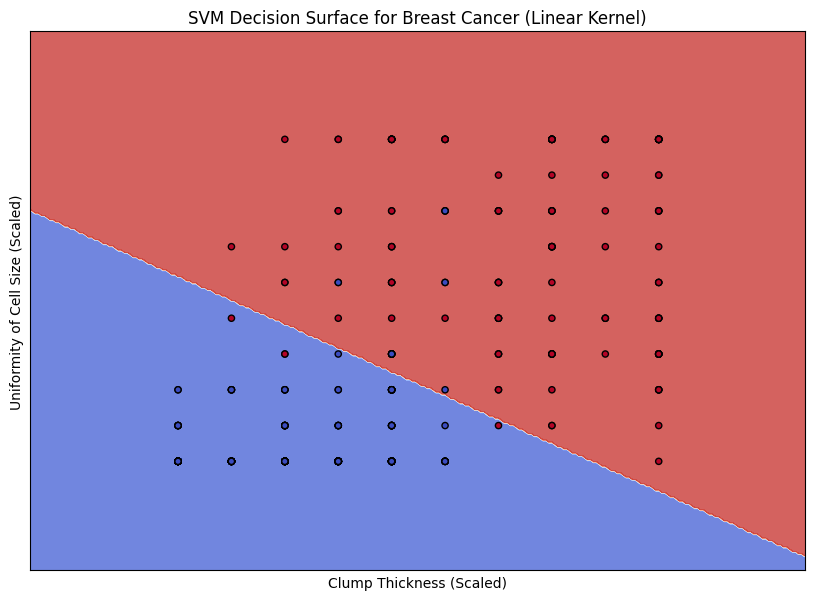

In [64]:
# Train a new SVC model with the 2D data
svm_model_2d = SVC(kernel='linear') # Using a linear kernel for simplicity first
svm_model_2d.fit(x_train_2d_scaled, y_train_2d.values.ravel()) # .ravel() to flatten y

# Create a mesh to plot the decision boundary
x_min, x_max = x_train_2d_scaled[:, 0].min() - 1, x_train_2d_scaled[:, 0].max() + 1
y_min, y_max = x_train_2d_scaled[:, 1].min() - 1, x_train_2d_scaled[:, 1].max() + 1
h = 0.02 # step size in the mesh
xx, yy = np.meshgrid(np.arange(x_min, x_max, h), np.arange(y_min, y_max, h))

# Predict classifications for each point in the mesh
Z = svm_model_2d.predict(np.c_[xx.ravel(), yy.ravel()])
Z = Z.reshape(xx.shape)

# Plot the decision boundary and the training points
plt.figure(figsize=(10, 7))
plt.contourf(xx, yy, Z, cmap=plt.cm.coolwarm, alpha=0.8)

# Plot also the training points
plt.scatter(x_train_2d_scaled[:, 0], x_train_2d_scaled[:, 1], c=y_train_2d.values.ravel(), cmap=plt.cm.coolwarm, edgecolors='k', s=20)
plt.xlabel('Clump Thickness (Scaled)')
plt.ylabel('Uniformity of Cell Size (Scaled)')
plt.title('SVM Decision Surface for Breast Cancer (Linear Kernel)')
plt.xlim(xx.min(), xx.max())
plt.ylim(yy.min(), yy.max())
plt.xticks(())
plt.yticks(())
plt.show()

We can also try a non-linear kernel like RBF if the data is not linearly separable.

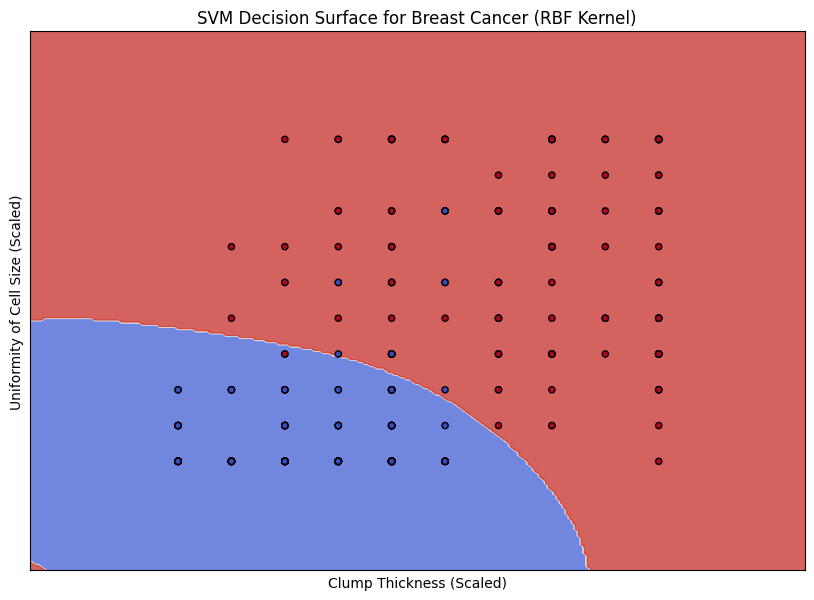

In [65]:
# Train a new SVC model with RBF kernel for the 2D data
svm_model_2d_rbf = SVC(kernel='rbf') # RBF kernel
svm_model_2d_rbf.fit(x_train_2d_scaled, y_train_2d.values.ravel())

# Predict classifications for each point in the mesh
Z_rbf = svm_model_2d_rbf.predict(np.c_[xx.ravel(), yy.ravel()])
Z_rbf = Z_rbf.reshape(xx.shape)

# Plot the decision boundary and the training points
plt.figure(figsize=(10, 7))
plt.contourf(xx, yy, Z_rbf, cmap=plt.cm.coolwarm, alpha=0.8)

# Plot also the training points
plt.scatter(x_train_2d_scaled[:, 0], x_train_2d_scaled[:, 1], c=y_train_2d.values.ravel(), cmap=plt.cm.coolwarm, edgecolors='k', s=20)
plt.xlabel('Clump Thickness (Scaled)')
plt.ylabel('Uniformity of Cell Size (Scaled)')
plt.title('SVM Decision Surface for Breast Cancer (RBF Kernel)')
plt.xlim(xx.min(), xx.max())
plt.ylim(yy.min(), yy.max())
plt.xticks(())
plt.yticks(())
plt.show()